# 05 - Scaling, resources and extensions

**Goal:** answer the challenge's question "how do quantum resources grow with
sequence length?", and try the two extensions that are actually interesting.

### How to run this notebook

This notebook runs on its own. You do not need the others open.

1. Put **gqe-rna.zip** at the top level of your Google Drive (My Drive).
   Do this once. You never need to unzip it yourself.
2. In Colab: **File -> Upload notebook** and pick this file.
3. **Runtime -> Change runtime type -> T4 GPU** (free tier is fine).
4. **Runtime -> Run all**. Approve the Drive popup when it appears.

Results are saved into `gqe-rna/results/` **in your Drive**, so they survive
when the runtime shuts down and the next notebook picks them up automatically.

If a cell says a file is missing, run the notebook it names first.

In [1]:
# STEP 1 - Connect to Drive and find the project.
# Put gqe-rna.zip at the top level of My Drive. Do not unzip it yourself.
import sys, os, glob, subprocess, importlib

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive"
REPO = os.path.join(ROOT, "gqe-rna")

# Unzip once, if the folder is not there yet.
if not os.path.isdir(os.path.join(REPO, "src")):
    zp = os.path.join(ROOT, "gqe-rna.zip")
    assert os.path.exists(zp), (
        "gqe-rna.zip was not found at the top level of My Drive. "
        "Upload it there (not in a subfolder), then run this cell again.")
    subprocess.run(["unzip", "-q", "-o", zp, "-d", ROOT], check=True)

# If the zip nested an extra folder, find the real one.
if not os.path.isdir(os.path.join(REPO, "src")):
    hits = glob.glob(os.path.join(ROOT, "**", "src", "colab_utils.py"),
                     recursive=True)
    assert hits, "Could not find src/ anywhere in My Drive after unzipping."
    REPO = os.path.dirname(os.path.dirname(hits[0]))

sys.path.insert(0, REPO)
importlib.invalidate_caches()   # Python cached this folder before it existed
from src import colab_utils as cu

cu.setup(repo=REPO)   # chdir into the project so results/ is saved to Drive
cu.install_vienna()

Mounted at /content/drive
project folder: /content/drive/MyDrive/gqe-rna
installing ViennaRNA ...


True

In [2]:
# STEP 2 - Load the project code.
import numpy as np
import matplotlib.pyplot as plt
from src import rna, energy, simulator, pools, metrics, baselines

rna.set_vienna_defaults()      # pin temperature and energy model
print("ViennaRNA available:", rna.HAVE_VIENNA)
cu.show_results()              # what earlier notebooks already saved

ViennaRNA available: True
file                        size   from notebook
--------------------------------------------------
baselines.pkl               2.0K   04
encoding.pkl                5.2K   02
gqe_model.pt             3113.9K   03
gqe_run.pkl                10.8K   03
refs.pkl                    0.5K   01


In [3]:
import time

## How many qubits does a sequence of length L need?

We measure this properly: 30 random sequences per length, not one example.

**Watch out:** random sequences have far fewer stems than real or designed
ones. The 44-base challenge sequence needs 27 qubits at min_len=3, while a
random 44-mer needs only about 10. Report both, and say which you used.

In [4]:
lengths = [15, 20, 25, 30, 35, 40, 50, 60]
counts = {3: [], 4: []}
for L in lengths:
    for m in (3, 4):
        vals = [len(rna.find_stems(rna.random_sequence(L, rng=1000+i), min_len=m))
                for i in range(30)]
        counts[m].append((np.mean(vals), np.std(vals)))
    print(f"L={L:3d}  min_len=3: {counts[3][-1][0]:5.1f}  min_len=4: {counts[4][-1][0]:5.1f}")

L= 15  min_len=3:   1.3  min_len=4:   0.3
L= 20  min_len=3:   2.7  min_len=4:   0.7
L= 25  min_len=3:   4.9  min_len=4:   1.4
L= 30  min_len=3:   8.0  min_len=4:   2.5
L= 35  min_len=3:  13.3  min_len=4:   4.5
L= 40  min_len=3:  17.7  min_len=4:   6.5
L= 50  min_len=3:  31.4  min_len=4:  10.8
L= 60  min_len=3:  46.6  min_len=4:  16.7


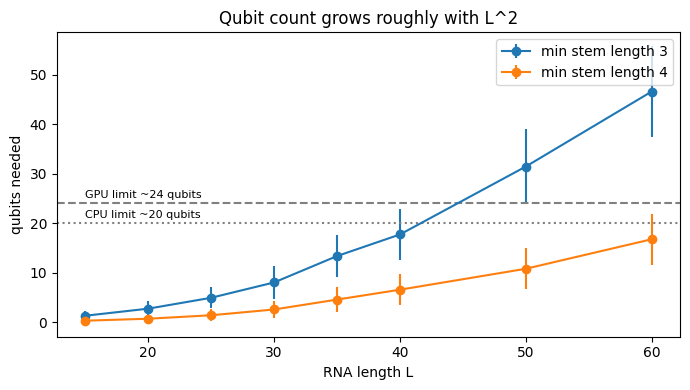

In [5]:
plt.figure(figsize=(7, 4))
for m, c_ in zip((3, 4), ("C0", "C1")):
    mu = np.array([x[0] for x in counts[m]]); sd = np.array([x[1] for x in counts[m]])
    plt.errorbar(lengths, mu, yerr=sd, marker="o", color=c_, label=f"min stem length {m}")
plt.axhline(20, ls=":", c="grey"); plt.text(15, 21, "CPU limit ~20 qubits", fontsize=8)
plt.axhline(24, ls="--", c="grey"); plt.text(15, 25, "GPU limit ~24 qubits", fontsize=8)
plt.xlabel("RNA length L"); plt.ylabel("qubits needed")
plt.legend(); plt.title("Qubit count grows roughly with L^2")
plt.tight_layout(); plt.show()

## Memory and runtime

A statevector for n qubits is 2^n complex numbers. We run a batch of B at
once, so memory is B times bigger. This is the real ceiling, and it is why we
cannot do min_len=3 on the 44-base challenge sequence (27 qubits).

In [6]:
print(f"{'n':>3} {'1 state':>10} {'batch of 16':>13}")
for n_ in range(14, 27):
    one = (1 << n_) * 8 / 1e6
    print(f"{n_:3d} {one:9.0f} MB {one*16:12.0f} MB")

  n    1 state   batch of 16
 14         0 MB            2 MB
 15         0 MB            4 MB
 16         1 MB            8 MB
 17         1 MB           17 MB
 18         2 MB           34 MB
 19         4 MB           67 MB
 20         8 MB          134 MB
 21        17 MB          268 MB
 22        34 MB          537 MB
 23        67 MB         1074 MB
 24       134 MB         2147 MB
 25       268 MB         4295 MB
 26       537 MB         8590 MB


In [7]:
# Measure how the simulator actually scales on this machine.
pool = pools.make_pool()
rows = []
for n_ in [10, 12, 14, 16, 18]:
    rng = np.random.default_rng(0)
    hh = rng.normal(size=n_)
    JJ = np.triu(rng.normal(size=(n_, n_)) * (rng.random((n_, n_)) < 0.4), 1)
    EE = energy.full_energy_vector(hh, JJ, dtype=np.float64)
    Es, _ = simulator.scale_energies(EE)
    s = simulator.Sim(Es, EE, pool, K=min(4096, len(EE)))
    toks = rng.integers(0, pool["size"], size=(16, 8))
    s.run(toks[:2])
    t0 = time.time(); s.run(toks); dt = time.time() - t0
    rows.append((n_, dt/16*1000))
    print(f"n={n_:2d}  {dt/16*1000:8.1f} ms per circuit")

n=10       9.0 ms per circuit
n=12       5.8 ms per circuit
n=14      11.1 ms per circuit
n=16      23.8 ms per circuit
n=18      25.1 ms per circuit


## Circuit depth: what this would cost on real hardware

Our cost gate is `exp(-i*gamma*H)`. On hardware that becomes one two-qubit
rotation per non-zero `J[k,m]` term, and each of those is two CNOTs.

In [8]:
enc = cu.require("encoding", made_by="02")
run = cu.require("gqe_run", made_by="03")
n, J = enc["n"], enc["J"]
n_terms = int((J > 0).sum())
n_cost_gates = sum(1 for t in run["best_tokens"] if pools.make_pool()["kind"][t] == 0)

print(f"qubits              : {n}")
print(f"two-qubit terms     : {n_terms}")
print(f"cost layers in circuit: {n_cost_gates}")
print(f"CNOTs (rough)       : {2 * n_terms * n_cost_gates}")
print()
print("For comparison, today's hardware manages a few hundred CNOTs before")
print("noise destroys the answer. This is the honest bottom line.")

qubits              : 22
two-qubit terms     : 184
cost layers in circuit: 4
CNOTs (rough)       : 1472

For comparison, today's hardware manages a few hundred CNOTs before
noise destroys the answer. This is the honest bottom line.


## Extension 1: pseudoknots

A pseudoknot is when two stems cross. Classical dynamic programming excludes
them because including them makes the problem NP-hard and breaks the algorithm.

In our QUBO it is **one flag**. That is the real argument for this formulation.

In [9]:
seq = enc["seq"]; stems = enc["stems"]

h_nested, J_nested = rna.build_qubo(seq, stems, allow_pseudoknots=False)
h_pk, J_pk = rna.build_qubo(seq, stems, allow_pseudoknots=True)

print("clash terms, nested          :", int((J_nested > 0).sum()))
print("clash terms, pseudoknots ok  :", int((J_pk > 0).sum()))
print("-> dropping the crossing rule removes",
      int((J_nested > 0).sum() - (J_pk > 0).sum()), "constraints")

E_n = energy.full_energy_vector(h_nested, J_nested, dtype=np.float64)
E_p = energy.full_energy_vector(h_pk, J_pk, dtype=np.float64)
print("\nbest nested QUBO energy      :", round(float(E_n.min()), 3))
print("best pseudoknotted QUBO energy:", round(float(E_p.min()), 3))

clash terms, nested          : 184
clash terms, pseudoknots ok  : 181
-> dropping the crossing rule removes 3 constraints

best nested QUBO energy      : -9.0
best pseudoknotted QUBO energy: -9.0


Careful how you report this. A lower QUBO energy does not automatically mean a
better structure: ViennaRNA cannot score pseudoknots, so we lose our reference.
The honest claim is "our formulation *can express* pseudoknots at no extra
cost", not "our pseudoknotted answer is more accurate".

## Extension 2: how noisy can we be?

GQE only needs the *ranking* of circuits to be right, not the exact energies.
So it should tolerate noise better than VQE. We test that by adding random
error to every energy the model sees.

In [10]:
noise_levels = [0.0, 0.05, 0.15, 0.30]
E = energy.full_energy_vector(enc["h"], enc["J"], dtype=np.float64)
spread = float(E.std())
rng = np.random.default_rng(0)

for s in noise_levels:
    noisy = E + rng.normal(0, s*spread, size=E.shape)
    order_true = np.argsort(E)[:20]
    order_noisy = np.argsort(noisy)[:20]
    overlap = len(set(order_true.tolist()) & set(order_noisy.tolist())) / 20
    print(f"noise {s:4.0%} of energy spread -> top-20 ranking preserved: {overlap:.0%}")

noise   0% of energy spread -> top-20 ranking preserved: 100%
noise   5% of energy spread -> top-20 ranking preserved: 40%
noise  15% of energy spread -> top-20 ranking preserved: 0%
noise  30% of energy spread -> top-20 ranking preserved: 0%


If the ranking survives, GQE should still train. That is a testable claim you
can put in your presentation: **GQE degrades gracefully because it learns an
ordering, not a value.** To go further, re-run notebook 03 with noise added
inside `sim.run` and compare the training curves.

## Limitations, stated plainly

Put these on a slide. Judges reward honesty.

1. Our QUBO models stem energies and clashes only. It does not model multiloop
   entropy, bulges, interior loops or dangling ends. The encoding error measured
   in notebook 02 is a hard floor.
2. We simulate up to about 20 qubits on CPU and 24 on GPU, which caps us at
   roughly L = 40 with min stem length 4.
3. Nested MFE folding is solved exactly in O(L^3) classically. We claim no
   speed advantage and never will for this version of the problem.
4. We did not run on real hardware. The CNOT count above shows why.
5. At n = 10 the search space is 1024 states, so every method finds the optimum.
   Separating methods needs bigger instances than we can simulate.

## Where this would actually be worth doing

- **Pseudoknots**, which are NP-hard classically and free in our encoding.
- **Multi-objective mRNA design**: fold energy plus codon usage, GC content and
  uridine depletion. Extra constraints break the dynamic programming approach
  but are just more QUBO terms for us. This is the Moderna-relevant direction.

## Save everything

This zips up `results/` and downloads it, so you have the plots and numbers
for your slides.

In [11]:
cu.show_results()
cu.download_results()      # downloads gqe-rna-results.zip to your computer

file                        size   from notebook
--------------------------------------------------
baselines.pkl               2.0K   04
encoding.pkl                5.2K   02
gqe_model.pt             3113.9K   03
gqe_run.pkl                10.8K   03
refs.pkl                    0.5K   01


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

download started: gqe-rna-results.zip


'gqe-rna-results.zip'